# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


C:\Users\Skylar\Downloads\tools\env\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import ipytest
import numpy as np
import pytest
import toolz as tz
from matplotlib import pyplot as plt
from sklearn import datasets as snds
from sklearn import ensemble as snee
from tools import typing as tstg
from tools import utils as tsus

ipytest.autoconfig(rewrite_asserts=False)

## Import other libraries

In [4]:
import typing

import numpy as np
import pandas as pd
import toolz as tz
from matplotlib import pyplot as plt
from sklearn import model_selection as snmos

## Declare constants

In [5]:
module: str = "model_selection"

# Define get_scores

## Define

In [6]:
def get_scores(display: snmos.LearningCurveDisplay | snmos.ValidationCurveDisplay, get_test: bool) -> pd.DataFrame:
    data: np.ndarray = getattr(display, "%s_scores" % ("test" if get_test else "train"))
    if isinstance(display, snmos.LearningCurveDisplay):
        index = pd.Index(data=display.train_sizes, name="train_sizes")
    else:
        index = pd.Index(data=display.param_range, name=display.param_name)
    scores = pd.DataFrame(data=data, index=index)
    return scores

## Demonstrate

<class 'tuple'> with 2 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (569, 30))
- element: 1
  (<class 'pandas.core.series.Series'>, (569,))
<class 'list'> with 4 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (455, 30))
- element: 1
  (<class 'pandas.core.frame.DataFrame'>, (114, 30))
- element: 2
  (<class 'pandas.core.series.Series'>, (455,))
- element: 3
  (<class 'pandas.core.series.Series'>, (114,))
Validation curve
--------------------------------------------------------------------------------


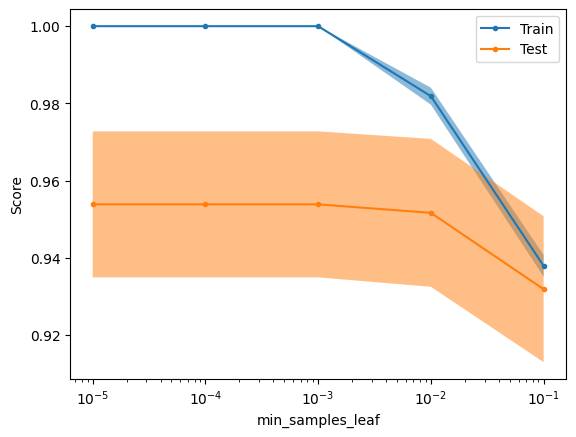

,0,1,2,3,4
min_samples_leaf,,,,,
0.00001,1.000000,1.000000,1.000000,1.000000,1.000000
0.00010,1.000000,1.000000,1.000000,1.000000,1.000000
0.00100,1.000000,1.000000,1.000000,1.000000,1.000000
0.01000,0.978022,0.980769,0.983516,0.983516,0.983516
0.10000,0.936813,0.934066,0.936813,0.939560,0.942308


,0,1,2,3,4
min_samples_leaf,,,,,
0.00001,0.945055,0.989011,0.956044,0.934066,0.945055
0.00010,0.945055,0.989011,0.956044,0.934066,0.945055
0.00100,0.945055,0.989011,0.956044,0.934066,0.945055
0.01000,0.945055,0.978022,0.967033,0.923077,0.945055
0.10000,0.901099,0.956044,0.945055,0.934066,0.923077


Learning curve
--------------------------------------------------------------------------------


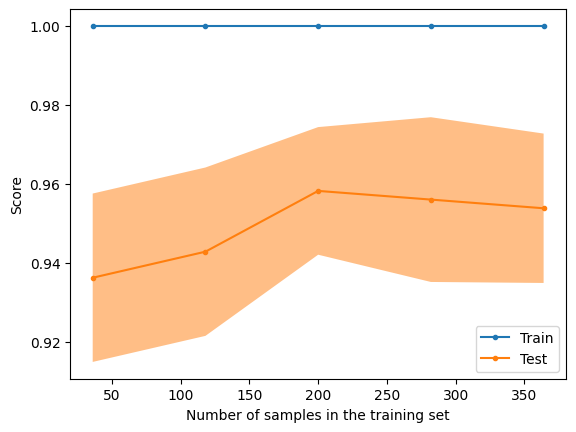

,0,1,2,3,4
train_sizes,,,,,
36,1.0,1.0,1.0,1.0,1.0
118,1.0,1.0,1.0,1.0,1.0
200,1.0,1.0,1.0,1.0,1.0
282,1.0,1.0,1.0,1.0,1.0
364,1.0,1.0,1.0,1.0,1.0


,0,1,2,3,4
train_sizes,,,,,
36,0.956044,0.945055,0.956044,0.923077,0.901099
118,0.978022,0.923077,0.956044,0.934066,0.923077
200,0.978022,0.967033,0.967033,0.934066,0.945055
282,0.978022,0.978022,0.956044,0.923077,0.945055
364,0.945055,0.989011,0.956044,0.934066,0.945055


In [7]:
def get_display(
    is_classification: bool,
    param_name: str | None,
    param_range: list | None,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int | None = None,
) -> snmos.LearningCurveDisplay | snmos.ValidationCurveDisplay:
    # Get estimator
    shared_args = dict(random_state=0)
    other_args = dict(class_weight="balanced_subsample") if is_classification else dict()
    random_forest_args = tz.merge(shared_args, other_args, dict(n_jobs=-1))
    RandomForest = snee.RandomForestClassifier if is_classification else snee.RandomForestRegressor
    random_forest = RandomForest(**random_forest_args)
    # Get cross-validator
    Splitter = snmos.StratifiedKFold if is_classification else snmos.KFold
    optional_args = dict(n_splits=n_splits) if n_splits is not None else dict()
    splitter_args = tz.merge(shared_args, optional_args)
    splitter = Splitter(shuffle=True, **splitter_args)
    # Get display
    Display = snmos.ValidationCurveDisplay if param_name is not None else snmos.LearningCurveDisplay
    args = dict(param_name=param_name, param_range=param_range) if param_range is not None else dict()
    return Display.from_estimator(estimator=random_forest, cv=splitter, X=X, y=y, line_kw=dict(marker="."), **args)


# Get data
X, y = data = snds.load_breast_cancer(return_X_y=True, as_frame=True)  # type: tuple[pd.DataFrame, pd.Series]
tsus.describe_structure(x=data)
# Split into train and test sets
X_train, X_test, y_train, y_test = splits = snmos.train_test_split(X, y, test_size=2e-1, stratify=y)  # type: list[pd.DataFrame | pd.Series]
tsus.describe_structure(x=splits)
# Get validation curve and scores
print("=" * int(8e1), "Validation curve", "-" * int(8e1), sep="\n")
shared_args = dict(is_classification=True, X=X_train, y=y_train)
vcd = get_display(
    param_name="min_samples_leaf", param_range=np.logspace(start=-5, stop=-1, num=5).tolist(), **shared_args
)
plt.show()
plt.close()
vcd_train_scores: pd.DataFrame = get_scores(display=vcd, get_test=False)
vcd_test_scores: pd.DataFrame = get_scores(display=vcd, get_test=True)
display(vcd_train_scores, vcd_test_scores)
# Get learning curve and scores
print("=" * int(8e1), "Learning curve", "-" * int(8e1), sep="\n")
lcd = get_display(param_name=None, param_range=None, **shared_args)
plt.show()
plt.close()
lcd_train_scores: pd.DataFrame = get_scores(display=lcd, get_test=False)
lcd_test_scores: pd.DataFrame = get_scores(display=lcd, get_test=True)
display(lcd_train_scores, lcd_test_scores)

## Test

In [8]:
%%ipytest

# Helper(s)
def make_data(is_classification: bool) -> tuple[pd.DataFrame, pd.Series]:
    make_fn: typing.Callable = snds.make_classification if is_classification else snds.make_regression
    X, y = data = make_fn()  # type: tuple[np.ndarray, np.ndarray]
    return pd.DataFrame(data=X).rename(columns=str), pd.Series(data=y)

# Property-based test(s)
@pytest.mark.parametrize('is_classification', [False, True])
@pytest.mark.parametrize('n_params', [3, 5])
@pytest.mark.parametrize('n_splits', [3, 5])
def test_get_scores(is_classification: bool, n_params: int, n_splits: int) -> None:
    shared_args = dict(is_classification=is_classification)
    X, y = make_data(**shared_args) # type: tuple[pd.DataFrame, pd.Series]
    param_range: list[float] = np.logspace(start=-n_params, stop=-1, num=n_params).tolist()
    vcd: snmos.ValidationCurveDisplay = get_display(
        param_name='min_samples_leaf', param_range=param_range, n_splits=n_splits, X=X, y=y, **shared_args
    )
    scores: pd.DataFrame = get_scores(display=vcd, get_test=True)
    plt.close()
    # Property 1: There are no NaNs
    assert scores.notna().all().all()
    # Property 2: Number of rows matches n_params
    assert scores.shape[0] == n_params
    # Property 3: Number of columns matches n_splits
    assert scores.shape[1] == n_splits

........                                                                                     [100%]
8 passed in 47.21s


# Define aggregate_scores

## Define

In [9]:
def aggregate_scores(scores: pd.DataFrame, is_simplest_smaller: bool, is_test: bool) -> pd.DataFrame:
    agg: str = "min" if is_simplest_smaller else "max"
    assign_args: dict[str, typing.Callable] = {
        "is_best": lambda x: x["mean"].pipe(func=lambda x: x.eq(other=x.max())),
        "best_mean": lambda x: x["mean"].where(cond=x["is_best"]).bfill().ffill(),
        "best_sem": lambda x: x["sem"].where(cond=x["is_best"]).bfill().ffill(),
        "best_lower": lambda x: x["best_mean"].sub(other=x["best_sem"]),
        "is_wi_1_sem": lambda x: x["mean"].ge(other=x["best_lower"]),
        "is_simplest_wi_1_sem": lambda x: x.index.__eq__(getattr(x.query(expr="is_wi_1_sem").index, agg)()),
    }
    return scores.agg(func=["mean", "sem"], axis=1).pipe(func=lambda x: x.assign(**assign_args) if is_test else x)

## Demonstrate

In [10]:
# Aggregate validation curve scores
shared_args = dict(is_simplest_smaller=False)
aggregated_vcd_train_scores: pd.DataFrame = aggregate_scores(scores=vcd_train_scores, is_test=False, **shared_args)
aggregated_vcd_test_scores: pd.DataFrame = aggregate_scores(scores=vcd_test_scores, is_test=True, **shared_args)
print("=" * int(8e1), "Validation curve", "-" * int(8e1), sep="\n")
display(aggregated_vcd_train_scores, aggregated_vcd_test_scores)
# Aggregate learning curve scores
shared_args.update(is_simplest_smaller=True)
aggregated_lcd_train_scores: pd.DataFrame = aggregate_scores(scores=lcd_train_scores, is_test=False, **shared_args)
aggregated_lcd_test_scores: pd.DataFrame = aggregate_scores(scores=lcd_test_scores, is_test=True, **shared_args)
print("=" * int(8e1), "Learning curve", "-" * int(8e1), sep="\n")
display(aggregated_lcd_train_scores, aggregated_lcd_test_scores)

Validation curve
--------------------------------------------------------------------------------


,mean,sem
min_samples_leaf,,
0.00001,1.000000,0.000000
0.00010,1.000000,0.000000
0.00100,1.000000,0.000000
0.01000,0.981868,0.001099
0.10000,0.937912,0.001401


,mean,sem,is_best,best_mean,best_sem,best_lower,is_wi_1_sem,is_simplest_wi_1_sem
min_samples_leaf,,,,,,,,
0.00001,0.953846,0.009453,True,0.953846,0.009453,0.944393,True,False
0.00010,0.953846,0.009453,True,0.953846,0.009453,0.944393,True,False
0.00100,0.953846,0.009453,True,0.953846,0.009453,0.944393,True,False
0.01000,0.951648,0.009580,False,0.953846,0.009453,0.944393,True,True
0.10000,0.931868,0.009453,False,0.953846,0.009453,0.944393,False,False


Learning curve
--------------------------------------------------------------------------------


,mean,sem
train_sizes,,
36,1.0,0.0
118,1.0,0.0
200,1.0,0.0
282,1.0,0.0
364,1.0,0.0


,mean,sem,is_best,best_mean,best_sem,best_lower,is_wi_1_sem,is_simplest_wi_1_sem
train_sizes,,,,,,,,
36,0.936264,0.010654,False,0.958242,0.008075,0.950167,False,False
118,0.942857,0.010654,False,0.958242,0.008075,0.950167,False,False
200,0.958242,0.008075,True,0.958242,0.008075,0.950167,True,True
282,0.956044,0.010425,False,0.958242,0.008075,0.950167,True,False
364,0.953846,0.009453,False,0.958242,0.008075,0.950167,True,False


## Test

In [11]:
%%ipytest

@pytest.mark.parametrize('is_classification', [False, True])
@pytest.mark.parametrize('param_name', ['min_samples_leaf', 'n_estimators'])
def test_get_scores(is_classification: bool, param_name: str) -> None:
    shared_args = dict(is_classification=is_classification)
    X, y = make_data(**shared_args) # type: tuple[pd.DataFrame, pd.Series]
    param_range: list[float] = np.logspace(start=0, stop=2, num=3, dtype=int).tolist()
    vcd: snmos.ValidationCurveDisplay = get_display(
        param_name=param_name, param_range=param_range, X=X, y=y, **shared_args
    )
    scores: pd.DataFrame = get_scores(display=vcd, get_test=True)
    plt.close()
    is_simplest_smaller: bool = False if param_name == 'min_samples_leaf' else True
    aggregated_scores: pd.DataFrame = aggregate_scores(scores=scores, is_simplest_smaller=is_simplest_smaller, is_test=True)
    # Property 1: There are no NaNs
    assert aggregated_scores.notna().all().all()
    # Property 2: There is exactly one simplest within 1 SEM
    assert aggregated_scores['is_simplest_wi_1_sem'].sum() == 1

....                                                                                         [100%]
4 passed in 15.34s


# Define plot_test_scores

## Define

In [12]:
def plot_test_scores(test_scores: pd.DataFrame, **kwargs) -> plt.Axes:
    # Get scores
    best_score: dict[typing.Any, float] = test_scores.query(expr="is_best")["mean"].to_dict()
    simplest_wi_1_sem_score: dict[typing.Any, float] = test_scores.query(expr="is_simplest_wi_1_sem")["mean"].to_dict()
    # Get title
    parts: list[str] = [
        "Best: %s / %.3f score" % next(iter(best_score.items())),
        "Simplest w/i 1 SEM: %s / %.3f score" % next(iter(simplest_wi_1_sem_score.items())),
    ]
    title: str = "\n".join(parts)
    # Plot error bars
    keys: list[str] = ["y", "yerr", "marker"]
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in keys, d=kwargs)
    shared_args = dict(y="mean")
    ax: plt.Axes = test_scores.plot(yerr="sem", marker=".", **filtered_kwargs, **shared_args)
    # Plot points
    shared_args.update(color="k", ax=ax)
    test_scores.query(expr="is_best").plot(marker="^", label="best", **shared_args)
    test_scores.query(expr="is_simplest_wi_1_sem").plot(marker="o", label="simplest", **shared_args)
    # Plot guide lines
    ax.axhline(y=test_scores["best_lower"].iloc[0], color="k", ls=":")
    list(map(lambda x: ax.axvline(x=next(iter(x)), c="k", ls=":"), [best_score, simplest_wi_1_sem_score]))
    # Set labels
    ax.set(ylabel="Mean +/- SEM", title=title)
    return ax

## Demonstrate

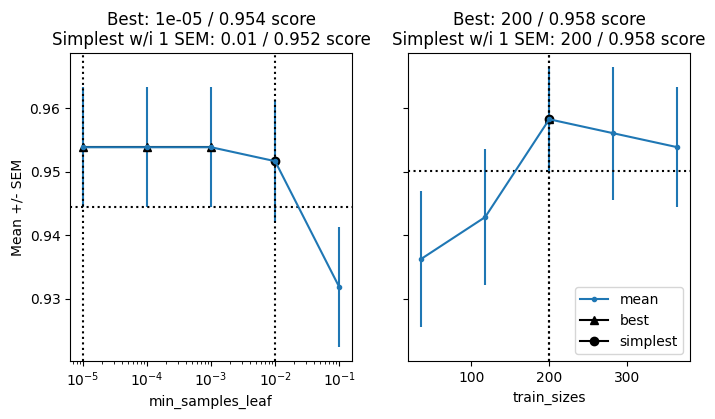

In [13]:
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(8, 4))  # typing: tstg.FigAxes
plot_test_scores(test_scores=aggregated_vcd_test_scores, ax=axes[0])
plot_test_scores(test_scores=aggregated_lcd_test_scores, ax=axes[1])
axes[0].set(xscale="log")
axes[0].get_legend().set_visible(b=False)
axes[1].get_legend().set_loc(loc="lower right")

## Test

In [14]:
# Placeholder

# Write module

## Write

In [15]:
module_path: str = "src/tools/%s.py" % module

In [16]:
%%file $module_path

import typing

import numpy as np
import pandas as pd
import toolz as tz
from matplotlib import pyplot as plt
from sklearn import model_selection as snmos

def aggregate_scores(scores: pd.DataFrame, is_simplest_smaller: bool, is_test: bool) -> pd.DataFrame:
    agg: str = "min" if is_simplest_smaller else "max"
    assign_args: dict[str, typing.Callable] = {
        "is_best": lambda x: x["mean"].pipe(func=lambda x: x.eq(other=x.max())),
        "best_mean": lambda x: x["mean"].where(cond=x["is_best"]).bfill().ffill(),
        "best_sem": lambda x: x["sem"].where(cond=x["is_best"]).bfill().ffill(),
        "best_lower": lambda x: x["best_mean"].sub(other=x["best_sem"]),
        "is_wi_1_sem": lambda x: x["mean"].ge(other=x["best_lower"]),
        "is_simplest_wi_1_sem": lambda x: x.index.__eq__(getattr(x.query(expr="is_wi_1_sem").index, agg)()),
    }
    return scores.agg(func=["mean", "sem"], axis=1).pipe(func=lambda x: x.assign(**assign_args) if is_test else x)

def get_scores(display: snmos.LearningCurveDisplay | snmos.ValidationCurveDisplay, get_test: bool) -> pd.DataFrame:
    data: np.ndarray = getattr(display, "%s_scores" % ("test" if get_test else "train"))
    if isinstance(display, snmos.LearningCurveDisplay):
        index = pd.Index(data=display.train_sizes, name="train_sizes")
    else:
        index = pd.Index(data=display.param_range, name=display.param_name)
    scores = pd.DataFrame(data=data, index=index)
    return scores

def plot_test_scores(test_scores: pd.DataFrame, **kwargs) -> plt.Axes:
    # Get scores
    best_score: dict[typing.Any, float] = test_scores.query(expr="is_best")["mean"].to_dict()
    simplest_wi_1_sem_score: dict[typing.Any, float] = test_scores.query(expr="is_simplest_wi_1_sem")["mean"].to_dict()
    # Get title
    parts: list[str] = [
        "Best: %s / %.3f score" % next(iter(best_score.items())),
        "Simplest w/i 1 SEM: %s / %.3f score" % next(iter(simplest_wi_1_sem_score.items())),
    ]
    title: str = "\n".join(parts)
    # Plot error bars
    keys: list[str] = ["y", "yerr", "marker"]
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in keys, d=kwargs)
    shared_args = dict(y="mean")
    ax: plt.Axes = test_scores.plot(yerr="sem", marker=".", **filtered_kwargs, **shared_args)
    # Plot points
    shared_args.update(color="k", ax=ax)
    test_scores.query(expr="is_best").plot(marker="^", label="best", **shared_args)
    test_scores.query(expr="is_simplest_wi_1_sem").plot(marker="o", label="simplest", **shared_args)
    # Plot guide lines
    ax.axhline(y=test_scores["best_lower"].iloc[0], color="k", ls=":")
    list(map(lambda x: ax.axvline(x=next(iter(x)), c="k", ls=":"), [best_score, simplest_wi_1_sem_score]))
    # Set labels
    ax.set(ylabel="Mean +/- SEM", title=title)
    return ax

Overwriting src/tools/model_selection.py


## Format

In [17]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [18]:
!ruff check $module_path

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\model_selection.py:33:49
   |
33 | def plot_test_scores(test_scores: pd.DataFrame, **kwargs) -> plt.Axes:
   |                                                 ^^^^^^^^
34 |     # Get scores
35 |     best_score: dict[typing.Any, float] = test_scores.query(expr="is_best")["mean"].to_dict()
   |

Found 1 error.


## Check with ty

In [19]:
!ty check $module_path

All checks passed!
